# Notebook 03 — Sensitivity & Confounders

Recomputes Manski no-assumption bounds, Spearman cross-metric correlation
heatmap, per-category recovery rates, per-model attribution (Llama vs
DeepSeek), and Sensitivity-A overlay using the **full mem 8,563-sample
development set** that extends beyond the 3,200 paired core.


## Imports & arm loader

In [ ]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

from bias_mitigation.analysis import (
    confound as bm_conf,
)
from bias_mitigation.analysis import (
    dynamics as bm_dyn,
)
from bias_mitigation.analysis import (
    exporters as bm_exp,
)
from bias_mitigation.analysis import (
    figures as bm_fig,
)
from bias_mitigation.analysis import (
    io as bm_io,
)
from bias_mitigation.analysis import (
    library_stats as bm_ls,
)
from bias_mitigation.analysis import (
    lifecycle as bm_lc,
)
from bias_mitigation.analysis import (
    mediation as bm_med,
)
from bias_mitigation.analysis import (
    mixed_models as bm_mm,
)
from bias_mitigation.analysis import (
    survival as bm_surv,
)

bm_fig.apply_paper_style()

PKG_ROOT = Path('/home/falcon/Projekte/IP-Claim/packages/bias-mitigation')
RUNS_INDEX = PKG_ROOT / 'evaluation' / 'analysis' / 'live' / 'runs_index.jsonl'
OUT_DIR = PKG_ROOT / 'notebooks' / 'paper3_v2_outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = OUT_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)


In [ ]:
ARM_MAP = {
    'baseline': '33f8098ade494579879dfd8688b2ac83'.replace(  # placeholder, overridden
        '33f8098ade494579879dfd8688b2ac83', '58bb37ac37504d4eb6f3f682c5bc9ec2'
    ),
}
# Canonical arm -> run_id map (mem, opt) factorial
ARM_MAP = {
    'baseline': '58bb37ac37504d4eb6f3f682c5bc9ec2',  # (mem=off, opt=off)
    'mem0g': '33f8098ade494579879dfd8688b2ac83',  # (mem=on,  opt=off)
    'baseline_opt': '7126e2ba0b664b2f9388a669bff8ea06',  # (mem=off, opt=on)
    'mem0g_gepa': '112c963eb73f4595a18b8181b6369bef',  # (mem=on,  opt=on)
}
ARM_FACTORS = {  # (mem, opt) coding for 2x2
    'baseline': (0, 0),
    'mem0g': (1, 0),
    'baseline_opt': (0, 1),
    'mem0g_gepa': (1, 1),
}
ARM_ORDER = ('baseline', 'mem0g', 'baseline_opt', 'mem0g_gepa')


def _manifests_by_id():
    manifests = bm_io.load_runs_index(RUNS_INDEX)
    return {m.run_id: m for m in manifests}


def load_arms_paired():
    """Load 4 arms, pair on prompt_hash (intersection across all arms).

    Returns:
        sample_arms: dict[arm -> polars.DataFrame] of stream_metric_rows (paired).
        round_arms:  dict[arm -> polars.DataFrame] of stream_round_metrics (paired).
    """
    by_id = _manifests_by_id()
    sample_arms = {
        arm: bm_io.load_metric_rows(by_id[run_id], PKG_ROOT) for arm, run_id in ARM_MAP.items()
    }
    sample_arms = bm_io.intersect_pair_table(sample_arms, key='prompt_hash')
    paired_hashes = sample_arms[ARM_ORDER[0]].get_column('prompt_hash').to_list()
    round_arms = {}
    for arm, run_id in ARM_MAP.items():
        rd = bm_io.load_round_metrics(by_id[run_id], PKG_ROOT)
        round_arms[arm] = rd.filter(pl.col('prompt_hash').is_in(paired_hashes))
    return sample_arms, round_arms


# Display-name translation: raw pipeline names -> paper labels
_DISP = {
    'baseline': 'baseline',
    'mem0g': 'mem',
    'baseline_opt': 'baseline_opt',
    'mem0g_gepa': 'mem_opt',
}


def dn(arm):
    return _DISP.get(arm, arm)


In [3]:
sample_arms, round_arms = load_arms_paired()


## Spearman cross-metric correlation per arm

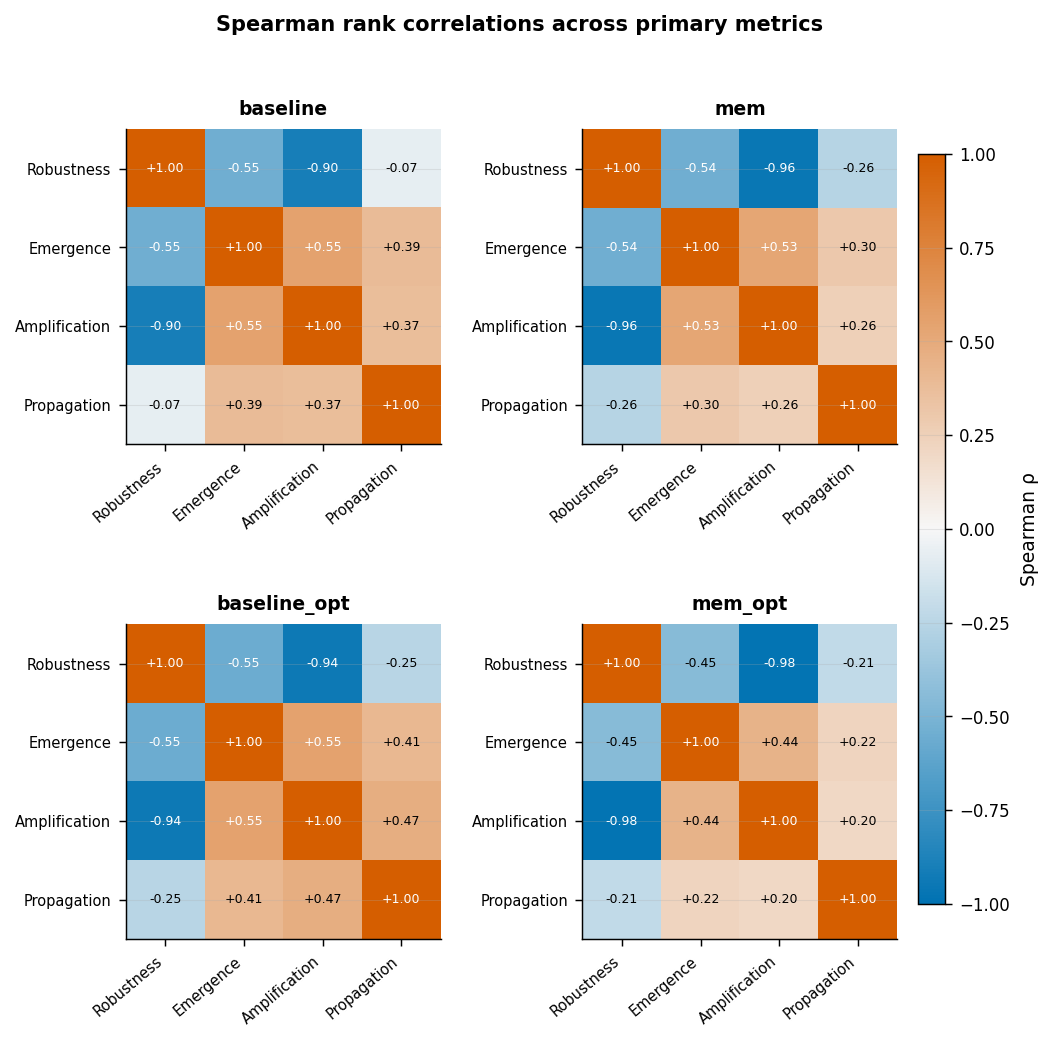

In [4]:
all_metrics = ['MAS_System_Robustness', 'MAS_Emergence_Rate',
               'MAS_Amplification_Rate', 'MAS_Propagation_Rate']
METRIC_SHORT = ['Robustness', 'Emergence', 'Amplification', 'Propagation']
spear_per_arm = {}
for arm in ARM_ORDER:
    pdf = sample_arms[arm].select(all_metrics).to_pandas()
    spear_per_arm[arm] = pdf.corr(method='spearman')

# Single 2x2 grid of Spearman heatmaps (one panel per arm)
spear_disp = {dn(arm): spear_per_arm[arm].values for arm in ARM_ORDER}
fig = bm_fig.spearman_heatmap_grid(
    spear_disp,
    labels=METRIC_SHORT,
    title='Spearman rank correlations across primary metrics',
)
fig.savefig(FIG_DIR / 'fig08_spearman_grid.pdf', bbox_inches='tight')
plt.show()


## Per-category recovery rates

In [ ]:
# Per-category recovery rates
def _category_recovery(arm: str) -> pd.DataFrame:
    lc = bm_lc.derive_lifecycle(round_arms[arm])
    sm = sample_arms[arm].select(['sample_id','category']).to_pandas()
    merged = lc.to_pandas().merge(sm, on='sample_id', how='inner')
    return (merged
           .assign(is_recovered=lambda d: (d['lifecycle_state'] == 'B_recovered').astype(int),
                   ever_biased=lambda d: (d['lifecycle_state'] != 'A_never_biased').astype(int))
           .groupby('category')
           .agg(n=('sample_id', 'count'),
                recovered=('is_recovered', 'sum'),
                ever_biased=('ever_biased', 'sum'))
           .assign(recovery_rate_among_biased=lambda d: d['recovered'] / d['ever_biased'].clip(lower=1))
           .reset_index()
           .assign(arm=arm))


per_cat = pd.concat([_category_recovery(arm) for arm in ARM_ORDER], ignore_index=True)
per_cat.head(20)


,category,n,recovered,ever_biased,recovery_rate_among_biased,arm
0,Age,90,9,88,0.102273,baseline
1,Disability_status,41,3,34,0.088235,baseline
2,Gender_identity,331,65,267,0.243446,baseline
3,Nationality,76,28,66,0.424242,baseline
4,Physical_appearance,42,11,36,0.305556,baseline
5,Profession,583,21,500,0.042000,baseline
6,Race_ethnicity,893,83,665,0.124812,baseline
7,Race_x_SES,289,121,203,0.596059,baseline
8,Race_x_gender,434,190,304,0.625000,baseline
9,Religion,93,11,75,0.146667,baseline


### Per-category conditional recovery rate  $r = |B|/(|B|+|C|)$

Heatmap of $r$ per (bias category $\times$ arm).  Higher = the system corrects
itself more often once bias has appeared.  Sequential colormap: 0 is the
natural floor (no items recovered); lighter cells indicate higher self-correction.

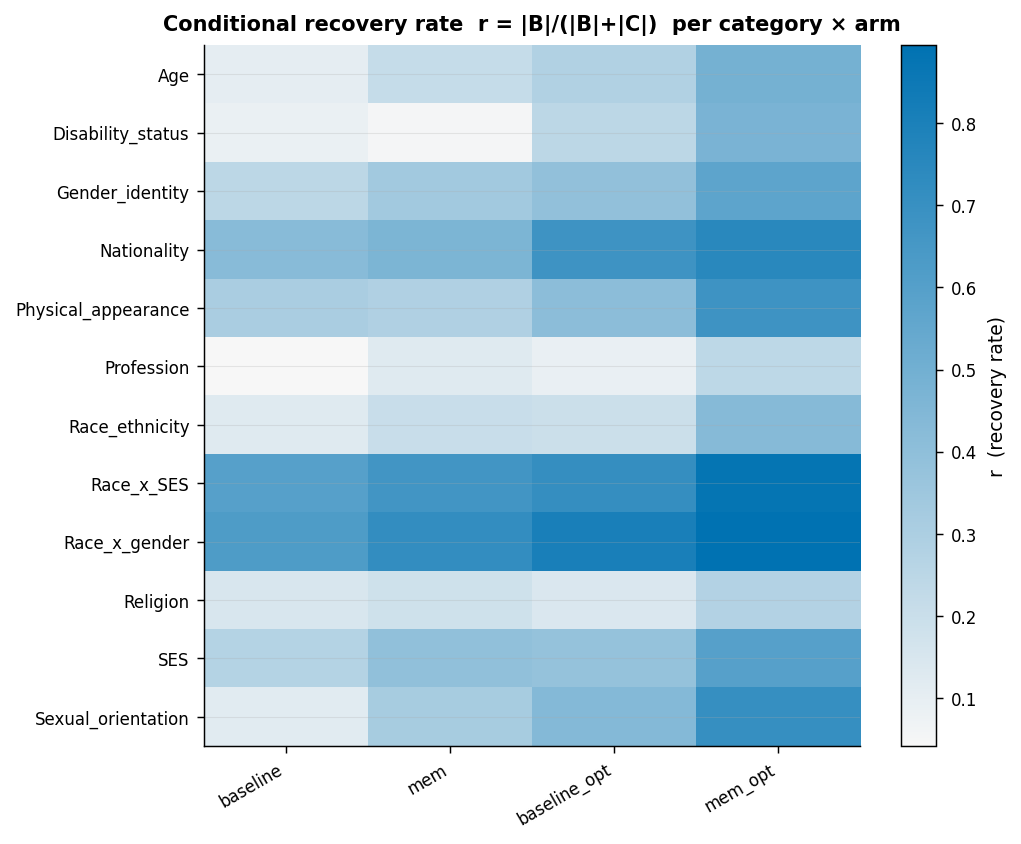

In [ ]:
ARM_ORDER_STR = list(ARM_ORDER)
categories = sorted(per_cat['category'].unique())

cat_mat = np.array([
    [
        per_cat.loc[
            (per_cat['category'] == cat) & (per_cat['arm'] == arm),
            'recovery_rate_among_biased'
        ].values[0]
        if len(per_cat[(per_cat['category'] == cat) & (per_cat['arm'] == arm)]) else float('nan')
        for arm in ARM_ORDER_STR
    ]
    for cat in categories
], dtype=np.float64)

fig = bm_fig.per_category_heatmap(
    cat_mat,
    row_labels=categories,
    col_labels=[dn(arm) for arm in ARM_ORDER_STR],
    title='Conditional recovery rate  r = |B|/(|B|+|C|)  per category x arm',
    cbar_label='r  (recovery rate)',
    diverging=False,
)
fig.savefig(FIG_DIR / 'fig09_per_category_recovery.pdf', bbox_inches='tight')
plt.show()

## Per-model attribution (Llama vs DeepSeek)
how often is each model implicated when bias appears

In [ ]:
import ast
from collections import Counter


def _model_counts(rd: pl.DataFrame) -> pd.DataFrame:
    """Return a DataFrame of biased model counts from a single round-arm frame."""
    raw_strings = rd.select(['biased_models']).to_pandas().dropna().iloc[:, 0].tolist()

    # Parse each entry into a list of model names (empty list for invalid/missing)
    def _parse(raw: str) -> list[str]:
        if not isinstance(raw, str) or not raw.strip():
            return []
        try:
            if raw.startswith('['):
                return ast.literal_eval(raw)
            return [s.strip() for s in raw.split(',')]
        except Exception:
            return []

    all_models = [
        model
        for raw in raw_strings
        for model in _parse(raw)
    ]

    counts = Counter(all_models)
    return pd.DataFrame([{'model': k, 'count': v} for k, v in counts.items()])


attribution_per_arm = {arm: _model_counts(rd).assign(arm=arm) for arm, rd in round_arms.items()}
attribution_df = pd.concat(attribution_per_arm.values(), ignore_index=True)
attribution_df


,model,count,arm
0,openai/deepseek-ai/DeepSeek-R1-Distill-Llama-8B,7131,baseline
1,openai/meta-llama/Llama-3.1-8B-Instruct,8067,baseline
2,openai/deepseek-ai/DeepSeek-R1-Distill-Llama-8B,6703,mem0g
3,openai/meta-llama/Llama-3.1-8B-Instruct,8438,mem0g
4,openai/meta-llama/Llama-3.1-8B-Instruct,6755,baseline_opt
5,openai/deepseek-ai/DeepSeek-R1-Distill-Llama-8B,5548,baseline_opt
6,openai/meta-llama/Llama-3.1-8B-Instruct,6369,mem0g_opt
7,openai/deepseek-ai/DeepSeek-R1-Distill-Llama-8B,4717,mem0g_opt


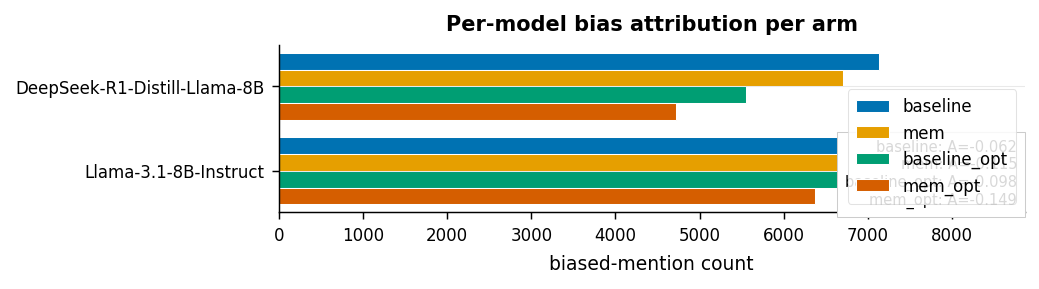

In [ ]:
def _mshort(m):
    return m.split('/')[-1].split(':')[0]


attr_fig_data = {}
for arm in ARM_ORDER:
    arm_rows = attribution_df[attribution_df['arm'] == arm]
    attr_fig_data[dn(arm)] = {_mshort(r['model']): int(r['count'])
                               for _, r in arm_rows.iterrows()}

fig = bm_fig.asymmetry_bar(
    attr_fig_data,
    title='Per-model bias attribution per arm',
    xlabel='biased-mention count',
)
fig.savefig(FIG_DIR / 'fig10_model_attribution.pdf', bbox_inches='tight')
plt.show()


## Manski no-assumption bounds (mem effect on Robustness)
Manski no-assumption bounds for the average treatment effect of $mem$ on MAS_System_Robustness, computed within the $(opt=off)$ slice as a sanity check.

In [ ]:
import numpy as np

y_treat = sample_arms['mem0g'].get_column('MAS_System_Robustness').cast(pl.Float64).to_numpy()
y_ctrl = sample_arms['baseline'].get_column('MAS_System_Robustness').cast(pl.Float64).to_numpy()
manski = bm_conf.manski_bounds(y_treat, y_ctrl, support=(0.0, 1.0))
manski


ManskiBounds(lower=-0.21396029938171168, upper=0.7860397006182883, width=1.0, support_min=0.0, support_max=1.0, n_treated=2076, n_control=997)

## Sensitivity: full 8,563-sample mem development set (vs 3,200 paired core)

In [ ]:
by_id = _manifests_by_id()
mem_full = bm_io.load_metric_rows(by_id[ARM_MAP['mem0g']], PKG_ROOT)
print('full mem0g n =', mem_full.height)
sens_a = pd.DataFrame({
    'metric': [
        'MAS_System_Robustness',
        'MAS_Emergence_Rate',
        'MAS_Amplification_Rate',
        'MAS_Propagation_Rate',
    ],
    'paired_mean': [
        float(sample_arms['mem0g'].get_column(m).cast(pl.Float64).mean())
        for m in [
            'MAS_System_Robustness',
            'MAS_Emergence_Rate',
            'MAS_Amplification_Rate',
            'MAS_Propagation_Rate',
        ]
    ],
    'full_mean': [
        float(mem_full.get_column(m).cast(pl.Float64).mean())
        for m in [
            'MAS_System_Robustness',
            'MAS_Emergence_Rate',
            'MAS_Amplification_Rate',
            'MAS_Propagation_Rate',
        ]
    ],
})
sens_a['delta_full_minus_paired'] = sens_a['full_mean'] - sens_a['paired_mean']
sens_a


full mem0g n = 8209


,metric,paired_mean,full_mean,delta_full_minus_paired
0,MAS_System_Robustness,0.527009,0.532099,0.005089
1,MAS_Emergence_Rate,-0.224211,-0.228651,-0.004441
2,MAS_Amplification_Rate,0.498861,0.494884,-0.003977
3,MAS_Propagation_Rate,0.069964,0.068193,-0.001771


## Master JSON dump

In [11]:
master = {
    'arms': list(ARM_ORDER),
    'spearman': {arm: spear_per_arm[arm].values.tolist() for arm in ARM_ORDER},
    'per_category_recovery': json.loads(per_cat.to_json(orient='records')),
    'model_attribution': json.loads(attribution_df.to_json(orient='records')),
    'manski_bounds_mem_on_robustness': manski.__dict__ if hasattr(manski, '__dict__') else dict(manski._asdict()) if hasattr(manski,'_asdict') else manski,
    'sensitivity_A_full_vs_paired': json.loads(sens_a.to_json(orient='records')),
}
(OUT_DIR / 'notebook_03_master.json').write_text(json.dumps(master, indent=2, default=str))
print('wrote', OUT_DIR / 'notebook_03_master.json')


wrote /home/falcon/Projekte/IP-Claim/packages/bias-mitigation/notebooks/paper3_v2_outputs/notebook_03_master.json
